In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOB_ARRAYS IS RUNNING
plotting=True

In [4]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

currently on type cloudy


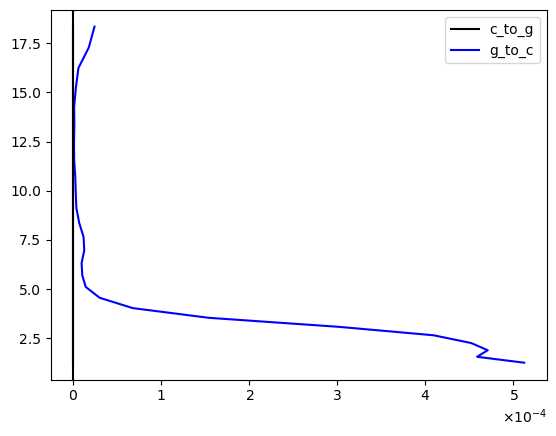

In [14]:
data_type='general'
data_type='cloudy'
if plotting==True:
    
    print(f'currently on type {data_type}')
    dir2=dir+'Project_Algorithms/Domain_Profiles/'
    if data_type == "general":
        input_file = dir2+f'job_out/general_eulerian_combined_entrainment_profiles_{res}_{t_res}_{Np_str}.h5' 
    elif data_type == "cloudy":
        input_file = dir2+f'job_out/cloudy_eulerian_combined_entrainment_profiles_{res}_{t_res}_{Np_str}.h5'
    
    with h5py.File(input_file, 'r') as f:
        c_to_g = np.array(f['profile_array_c_to_g'])
        g_to_c = np.array(f['profile_array_g_to_c'])
    
    #Uses Averaged_Profiles Function
    vars = ['c_to_g','g_to_c'] 
    
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(globals()[f"{var}"])
    
    
    plt.plot(out_c_to_g[:,0],out_c_to_g[:,1],color='black',label='c_to_g')
    plt.plot(out_g_to_c[:,0],out_g_to_c[:,1],color='blue',label='g_to_c')
    plt.axvline(0,color='k')
    ax = plt.gca()
    apply_scientific_notation([ax])

    if type=='cloudy':
        plt.title('Cloudy Entrainment Within Cloudy Updrafts')
    elif type=='general':
        plt.title('General Entrainment Within General Updrafts')
    plt.legend()